In [5]:
# Array and data functions
import numpy as np
from glob import glob
import pandas as pd

# Plotting
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Measuring
from skimage import io
from skimage.morphology import binary_erosion, binary_dilation, skeletonize, medial_axis
from scipy.ndimage import distance_transform_edt
from MEDUSSA.measure import SkeletonMeasure


from scipy.stats import mode

import warnings
warnings.filterwarnings('ignore')

In [2]:
BasePath ='/Volumes/evocell/Microscopy/Octavio/Strains/VegetativeCells/Round1/Processed_masks/Finalized/Bacillus subtilis subspecies subtilis/*PY79_t5_003*' 

masks = io.imread(glob(BasePath)[0])
cells = SingleCellLister([masks])

i = 22

cell = cells[i]

io.imsave(arr = cell, fname = '/Users/reyesmatte/Desktop/Imaging_paper/branching_skeleton_example.tif')

In [6]:
cell = io.imread('/Users/reyesmatte/Desktop/Imaging_paper/branching_skeleton_example.tif')

cell = np.pad(pad_width=4,array=cell)
cell = binary_dilation(binary_erosion(cell))

L,w,S,V,paths = SkeletonMeasure(skeletonize(cell),distance_transform_edt(cell),return_paths=True)


In [8]:
imgs = []

for path in paths:
    
    newimg = np.zeros((80,80))
    empty = np.zeros(cell.shape)
    
    for point in path:
        
        x,y = point
        empty[y,x] = 1
    
    newimg2 = newimg
    newimg2[20:59,5:74] = empty
    imgs.append(newimg2)


cell2 = np.zeros((80,80))
cell2[20:59,5:74] = cell

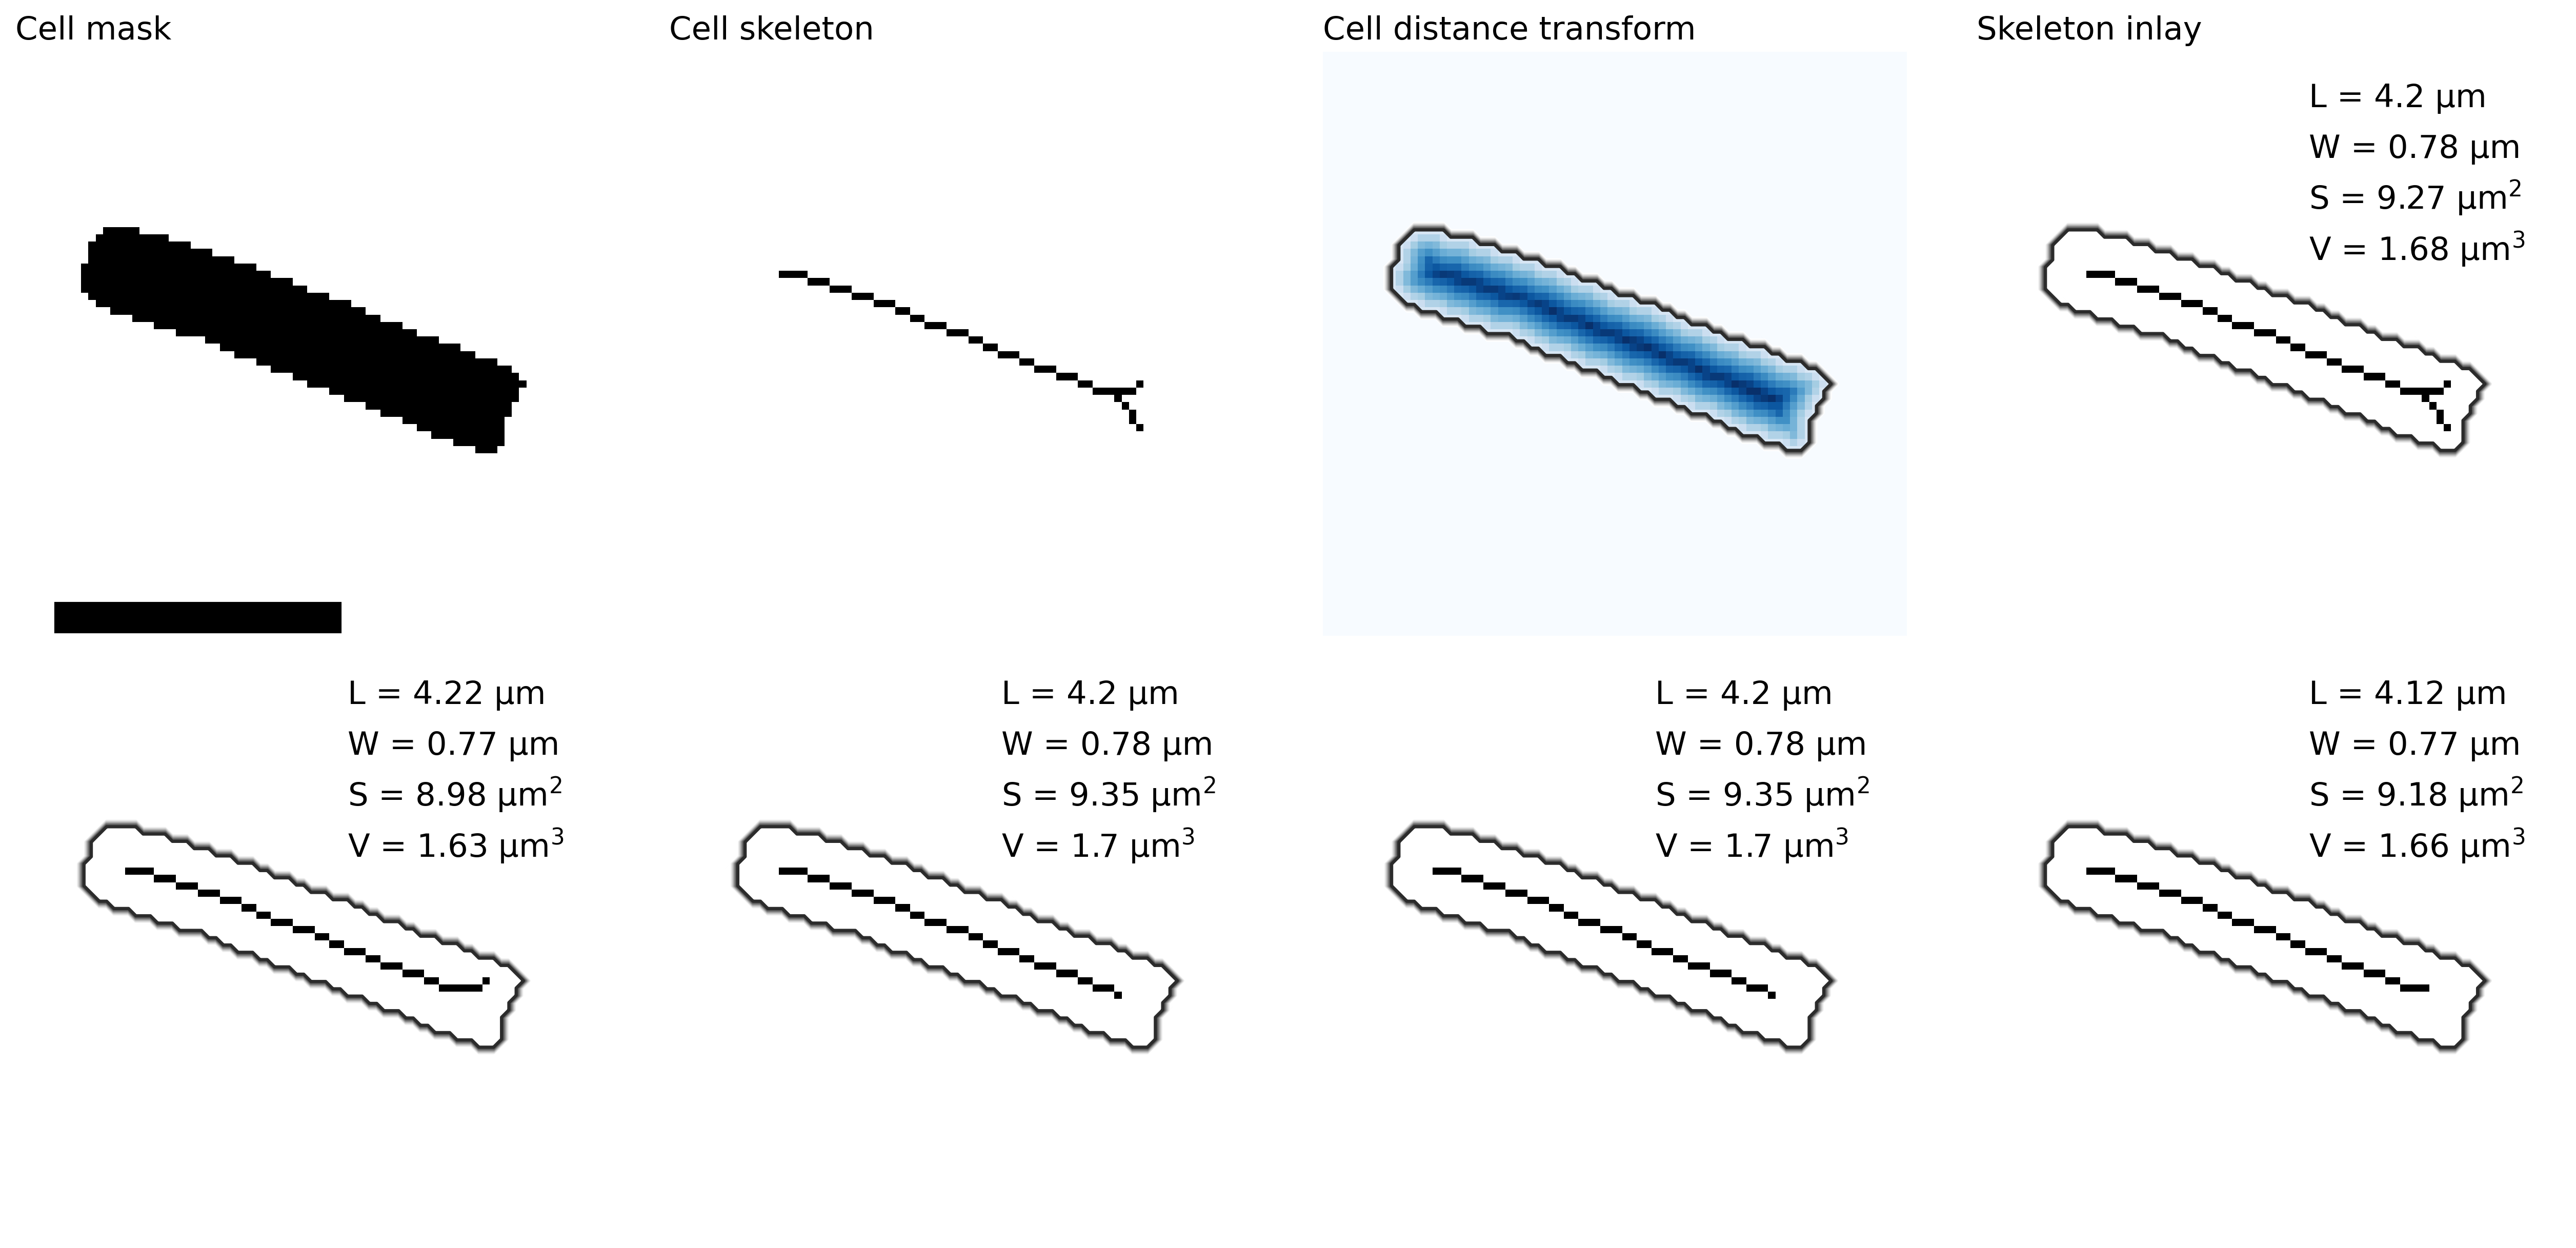

In [10]:
fig,ax = plt.subplots(dpi=300,constrained_layout=True,figsize=(17,8),ncols=4,nrows=2)
patch = patches.Rectangle((5, 75), 39, 4, linewidth=1, edgecolor='black', facecolor='black')

ax[0,0].imshow(cell2,cmap='Greys')
ax[0,0].add_patch(patch)
ax[0,0].axis('off')
ax[0,0].set_title('Cell mask', loc='left',fontsize=15)

plt.subplot(2,4,2)
plt.imshow(skeletonize(cell2),cmap='Greys')
plt.axis('off')
plt.title('Cell skeleton', loc='left',fontsize=15)

plt.subplot(2,4,3)
plt.contour(cell2,cmap='Greys')
plt.imshow(distance_transform_edt(cell2),cmap='Blues')
plt.axis('off')
plt.title('Cell distance transform', loc='left',fontsize=15)

plt.subplot(2,4,4)
plt.contour(cell2,cmap='Greys')
plt.imshow(skeletonize(cell2),cmap='Greys')
plt.axis('off')
plt.title('Skeleton inlay', loc='left',fontsize=15)

i = 0
j = 5
for img in imgs:
    
    plt.subplot(2,4,j)
    plt.contour(cell2,cmap='Greys')
    plt.imshow(imgs[i],cmap='Greys')
    plt.text(x=45,y=7,s=f'L = {np.round(L[i],2)} µm',c='k',fontsize=15)
    plt.text(x=45,y=14,s=f'W = {np.round(w[i],2)} µm',c='k',fontsize=15)
    plt.text(x=45,y=21,s=f'S = {np.round(S[i],2)} µm$^2$',c='k',fontsize=15)
    plt.text(x=45,y=28,s=f'V = {np.round(V[i],2)} µm$^3$',c='k',fontsize=15)
    plt.axis('off')

    j+=1
    i+=1

plt.subplot(2,4,4)
plt.text(x=45,y=7,s=f'L = {np.round(np.median(L),2)} µm',c='k',fontsize=15)
plt.text(x=45,y=14,s=f'W = {np.round(np.median(w),2)} µm',c='k',fontsize=15)
plt.text(x=45,y=21,s=f'S = {np.round(np.median(S),2)} µm$^2$',c='k',fontsize=15)
plt.text(x=45,y=28,s=f'V = {np.round(np.median(V),2)} µm$^3$',c='k',fontsize=15)

fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/FigS8/Branching_example.png')

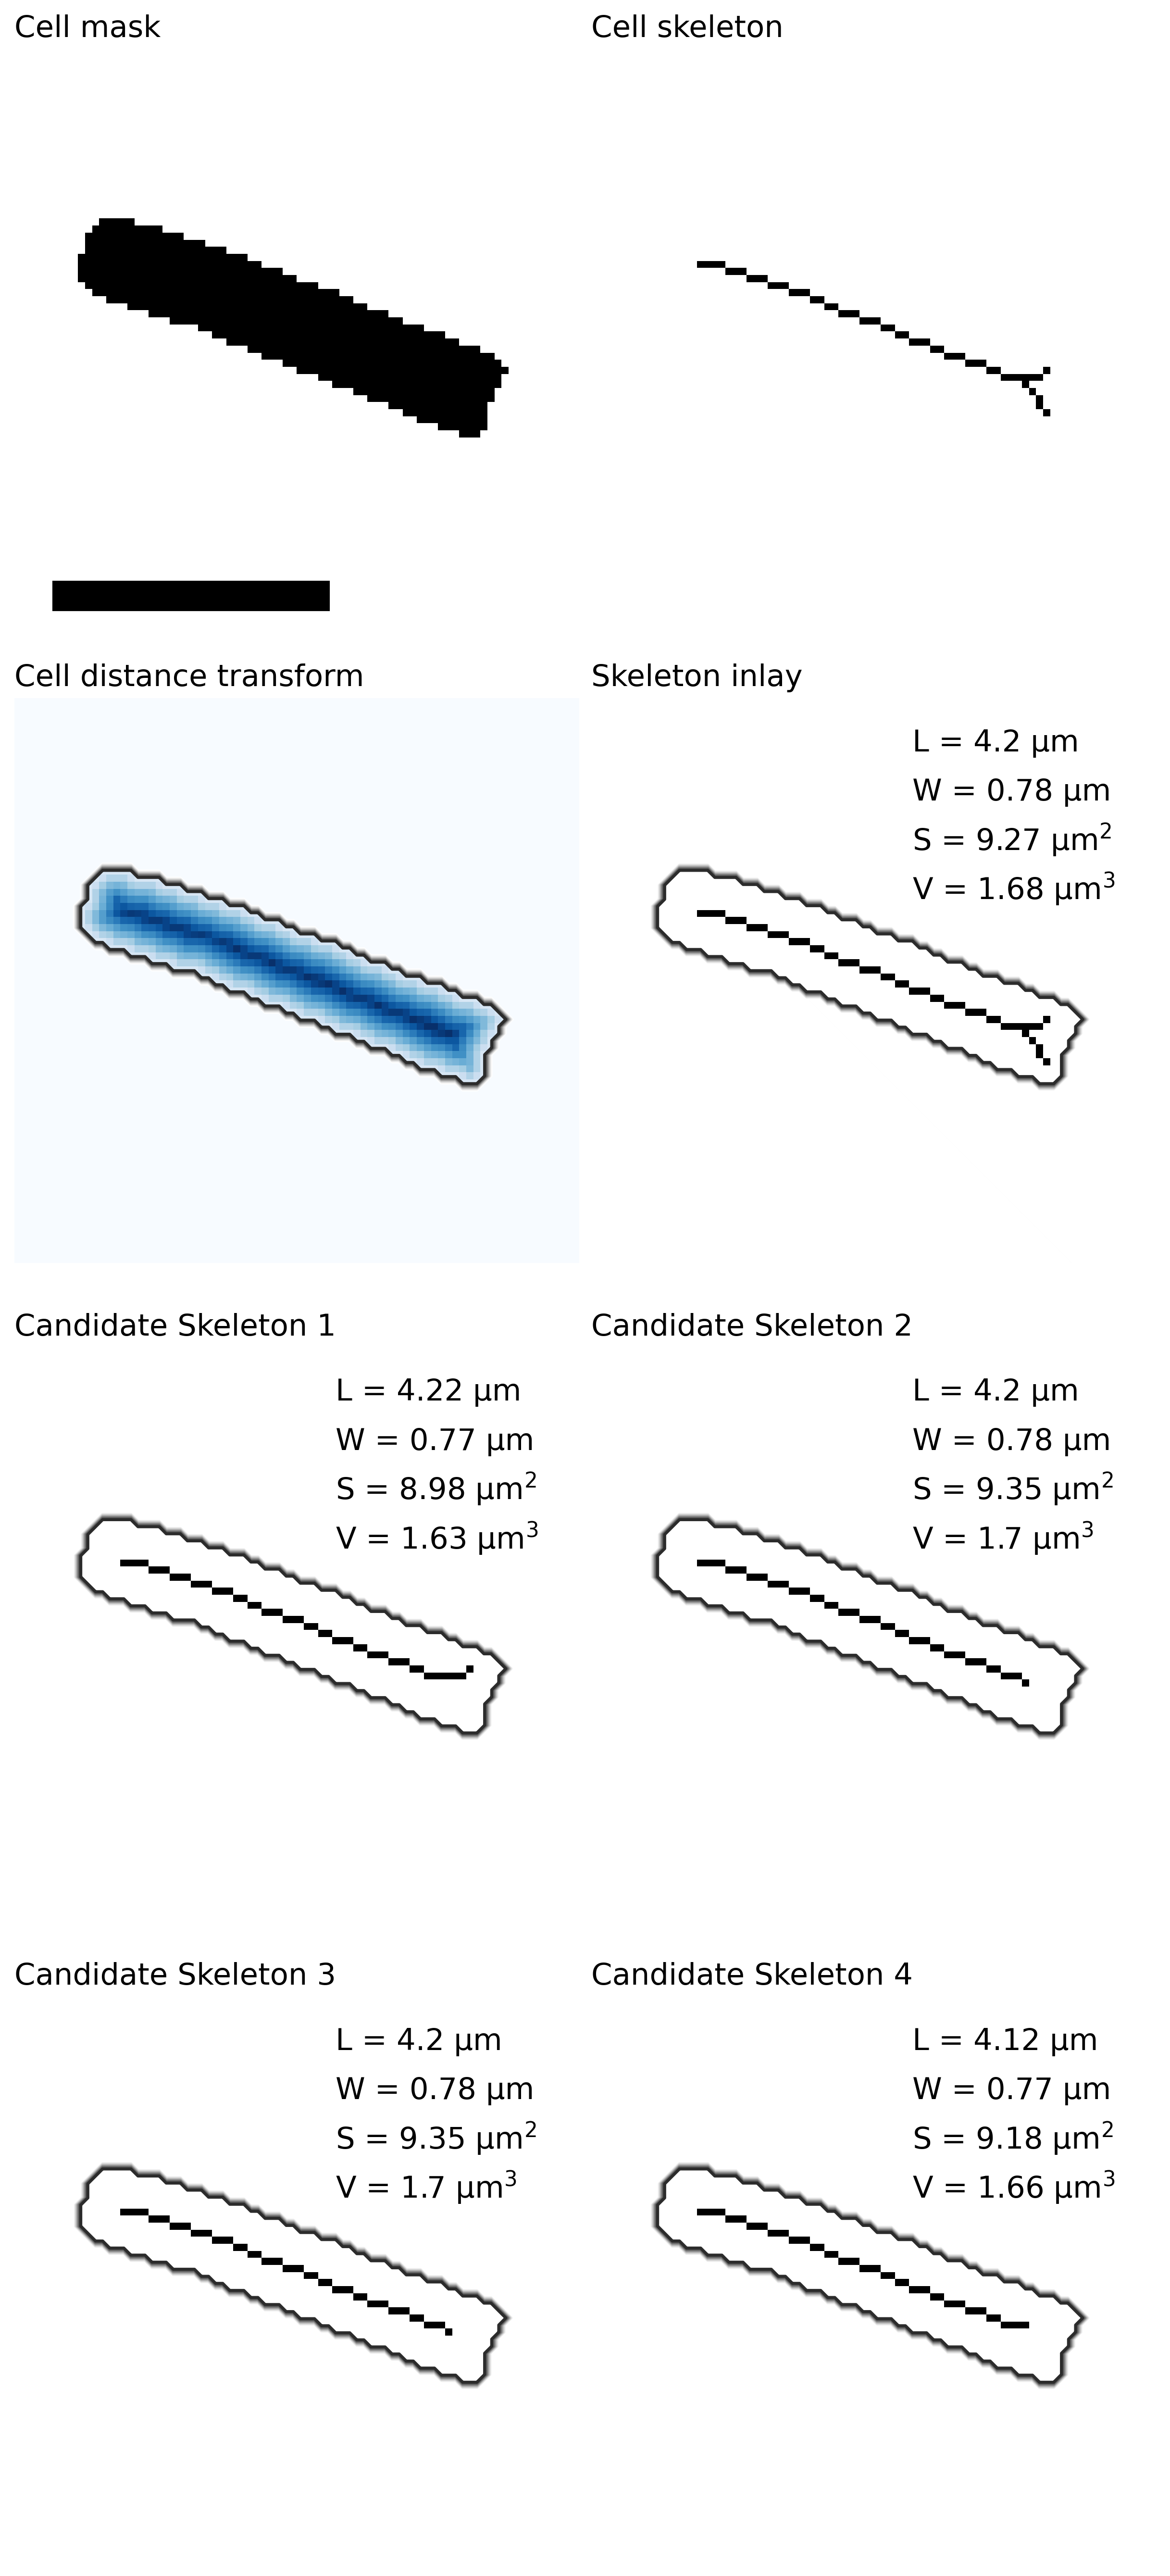

In [30]:
fig,ax = plt.subplots(dpi=300,constrained_layout=True,figsize=(8,18),nrows=4,ncols=2)

patch = patches.Rectangle((5, 75), 39, 4, linewidth=1, edgecolor='black', facecolor='black')

ax[0,0].imshow(cell2,cmap='Greys')
ax[0,0].add_patch(patch)
ax[0,0].axis('off')
ax[0,0].set_title('Cell mask', loc='left',fontsize=15)

plt.subplot(4,2,2)
plt.imshow(skeletonize(cell2),cmap='Greys')
plt.axis('off')
plt.title('Cell skeleton', loc='left',fontsize=15)

plt.subplot(4,2,3)
plt.contour(cell2,cmap='Greys')
plt.imshow(distance_transform_edt(cell2),cmap='Blues')
plt.axis('off')
plt.title('Cell distance transform', loc='left',fontsize=15)

plt.subplot(4,2,4)
plt.contour(cell2,cmap='Greys')
plt.imshow(skeletonize(cell2),cmap='Greys')
plt.axis('off')
plt.title('Skeleton inlay', loc='left',fontsize=15)

i = 0
j = 5

for img in imgs:
    
    plt.subplot(4,2,j)
    plt.contour(cell2,cmap='Greys')
    plt.imshow(imgs[i],cmap='Greys')
    plt.text(x=45,y=7,s=f'L = {np.round(L[i],2)} µm',c='k',fontsize=15)
    plt.text(x=45,y=14,s=f'W = {np.round(w[i],2)} µm',c='k',fontsize=15)
    plt.text(x=45,y=21,s=f'S = {np.round(S[i],2)} µm$^2$',c='k',fontsize=15)
    plt.text(x=45,y=28,s=f'V = {np.round(V[i],2)} µm$^3$',c='k',fontsize=15)
    plt.axis('off')
    plt.title(f'Candidate Skeleton {i+1}', loc='left',fontsize=15)

    j+=1
    i+=1

plt.subplot(4,2,4)
plt.text(x=45,y=7,s=f'L = {np.round(np.median(L),2)} µm',c='k',fontsize=15)
plt.text(x=45,y=14,s=f'W = {np.round(np.median(w),2)} µm',c='k',fontsize=15)
plt.text(x=45,y=21,s=f'S = {np.round(np.median(S),2)} µm$^2$',c='k',fontsize=15)
plt.text(x=45,y=28,s=f'V = {np.round(np.median(V),2)} µm$^3$',c='k',fontsize=15)

fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/FigS8/Branching_example_vertical.png')